In [1]:
import os
import pickle

dir = "../../bash_scripts/data_g2/20260212_083115"

d = {}

for folder in os.listdir(dir):

    # get the parameters from dir name
    hg, gamma, phi = folder.split('_')
    hg, gamma, phi = float(hg), float(gamma), float(phi)

    # load the results pkl as dict
    with open(os.path.join(dir, folder, 'results.pkl'), 'rb') as fp:
        d_result = pickle.load(fp)

    # check if entries already loaded, otherwise initialize
    if hg not in d:
        d[hg] = {}
    if gamma not in d[hg]:
        d[hg][gamma] ={}

    # store loaded results
    d[hg][gamma][phi] = d_result

list_hg = list(d.keys())
list_gamma = list(d[list_hg[0]].keys())
list_phi = list(d[list_hg[0]][list_gamma[0]].keys())

list_hg.sort(), list_gamma.sort(), list_phi.sort()

ks = d[10][0.00][0.0]['ks']
data_shape = d[10][0.00][0.0]['g2s'].shape

print(f"hg: {list_hg}")
print(f"gamma: {list_gamma}")
print(f"phi: {list_phi}")
    

hg: [10.0, 50.0, 700.0]
gamma: [0.0, 0.02, 0.04, 0.06, 0.08, 0.1]
phi: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


# Plot a single g2 outcome, function of k

g2_min: 0.8216429463829514, with n: 0.00033732411769184185


g2_min: 0.503511740753363, with n: 0.00033730241419836294
g2_min: 0.5020514695073821, with n: 0.024752309627542983


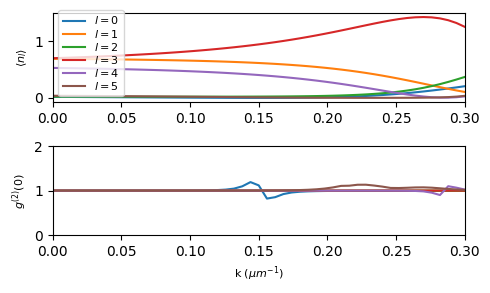

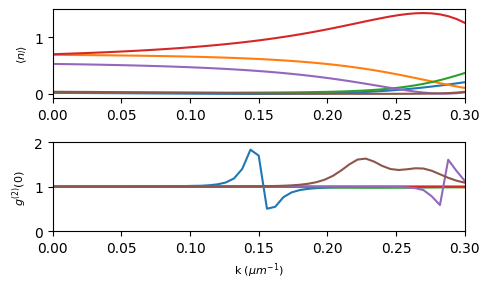

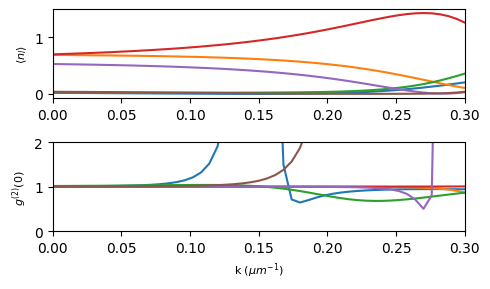

In [16]:
import matplotlib.pyplot as plt
import numpy as np


gamma = .0
phi = .6

for i, hg in enumerate(list_hg):

    ks = d[hg][gamma][phi]['ks']
    g2s = d[hg][gamma][phi]['g2s']
    ns = d[hg][gamma][phi]['ns']

    legend = [rf"$l={i}$" for i in range(d[hg][gamma][phi]['parameters']['num_channels'])]


    # Find the flat index of the smallest element in g2s
    flat_min_idx = np.argmin(g2s)               # returns a single integer

    # Convert that flat index back to a 2‑D (row, col) coordinate
    row, col = np.unravel_index(flat_min_idx, g2s.shape)

    # Pull out the minimum value and the matching n‑value
    g2_min   = g2s[row, col]
    n_at_min = ns[row, col]

    # Print the result
    print(f"g2_min: {g2_min}, with n: {n_at_min}")

    fig, ax = plt.subplots(2,1, figsize=(5,3))
    ax[0].plot(ks, ns)
    ax[0].set_ylabel(r"$\langle n_l \rangle$", fontsize=8)
    ax[0].set_xlim([np.min(ks), np.max(ks)])
    #ax[0].set_xlabel(r"k $(\mu m ^{-1})$", fontsize=8)

    if i==0:
        ax[0].legend(legend, loc="lower left", fontsize=8, labelspacing=0.1)


    max_g2 = 2 #np.minimum(np.max(g2s), 2.)
    min_g2 = 0 # np.min(g2s)

    ax[1].plot(ks, g2s)
    ax[1].set_xlabel(r"k $(\mu m ^{-1})$", fontsize=8)
    ax[1].set_ylabel(r"$g^{(2)}(0)$", fontsize=8)
    ax[1].set_ylim(bottom=min_g2,top=max_g2)
    ax[1].set_xlim([np.min(ks), np.max(ks)])
    fig.tight_layout()

    fig.show()

# Minimal g2 value, as function of phi

In [18]:
import numpy as np

ks = d[10][0.00][0.0]['ks']

g2_min = np.zeros((len(list_hg), len(list_gamma)))
n_g2_min = np.zeros((len(list_hg), len(list_gamma)))

for ih, hg in enumerate(list_hg):
    for ig, gamma in enumerate(list_gamma):
        g2_min_phi = [np.nanmin(d[hg][gamma][phi]['g2s']) for phi in list_phi]
        g2_min[ih,ig] = np.min(g2_min_phi)

        g2_min_arg_phi = [np.unravel_index(np.argmin(d[hg][gamma][phi]['g2s']), data_shape) for phi in list_phi]
        g2_min_arg = g2_min_arg_phi[np.argmin(g2_min_phi)]

        n_g2_min[ih,ig] = d[hg][gamma][phi]['ns'][g2_min_arg]
        

    

In [19]:
g2_min.shape

(3, 6)

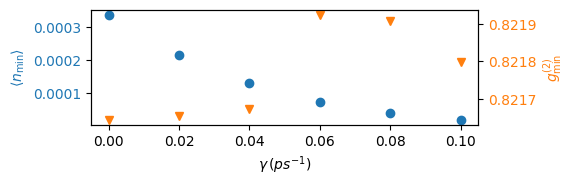

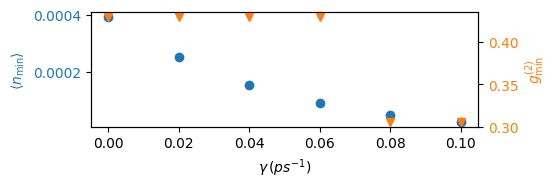

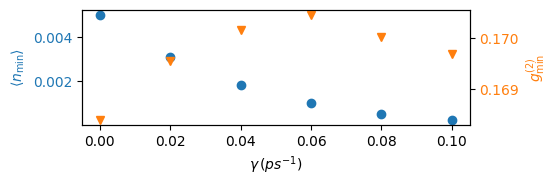

In [21]:

for i, hg in enumerate(list_hg):
    fig, ax1 = plt.subplots(figsize=(5,1.5))

    # left y-axis (blue)
    ax1.plot(list_gamma, n_g2_min[i], "o", color="tab:blue")
    ax1.set_xlabel(r"$\gamma\, (ps^{-1})$")
    ax1.set_ylabel(r"$\langle n_\mathrm{min} \rangle$", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # right y-axis (orange)
    ax2 = ax1.twinx()
    ax2.plot(list_gamma, g2_min[i], "v", color="tab:orange")
    ax2.set_ylabel(r"$g^{(2)}_\text{min}$", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    plt.show()



In [5]:
np.min([np.nanmin(d[700][0.0][phi]['g2s']) for phi in list_phi])

np.float64(0.16840273246790843)

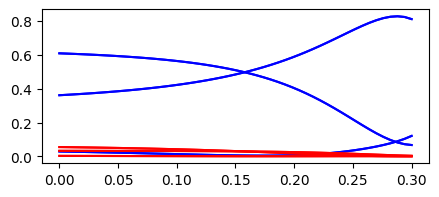

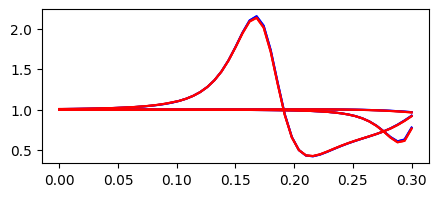

In [6]:
hg = 700
gammas = [0., 0.1]
phi = 1.

plt.figure(figsize=(5,2))
plt.plot(ks, d[hg][gammas[0]][phi]['ns'],'b')
plt.plot(ks, d[hg][gammas[1]][phi]['ns'], 'r')
plt.show()

plt.figure(figsize=(5,2))
plt.plot(ks, d[hg][gammas[0]][phi]['g2s'],'b')
plt.plot(ks, d[hg][gammas[1]][phi]['g2s'], 'r')
plt.show()

In [7]:
from qutip import *

